# Chaotic systems

Chaotic systems are *deterministic* yet unpredictable: fully specified equations whose sensitivity to initial conditions produces series that look random but have rich hidden structure. They test whether a model captures nonlinear dynamics rather than just fitting noise.

::: {.callout-note}
## The model

Choose a classic system via `system` — `lorenz` (a strange attractor), `logistic` (the period-doubling map), or `mackey_glass` (a delay-differential equation). Each is generated by iterating its exact dynamics, so the same seed and parameters reproduce the trajectory precisely.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import ChaoticSystemGenerator

## 1. Lorenz attractor

The Lorenz system is a classic example of deterministic chaos, producing butterfly-shaped trajectories with sensitive dependence on initial conditions.

In [ ]:
lorenz_gen = ChaoticSystemGenerator(engine="polars", 
    min_length=500,
    max_length=500,
    freq="D",
    system="lorenz",
    sigma=10.0,
    rho=28.0,
    beta_param=8.0 / 3.0,
    observation_noise=0.1,
    seed=42,
)
lorenz_df = lorenz_gen.generate(n_series=1)

print(f"Generated {len(lorenz_df)} observations from Lorenz system")
print(f"Statistics: Mean={lorenz_df['y'].mean():.4f}, Std={lorenz_df['y'].std():.4f}")
lorenz_df.head(10)

Generated 500 observations from Lorenz system
Statistics: Mean=-0.6576, Std=7.8972


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,1.807641
"""0""",2000-01-02 00:00:00,-3.607801
"""0""",2000-01-03 00:00:00,11.627439
"""0""",2000-01-04 00:00:00,0.082917
"""0""",2000-01-05 00:00:00,3.613951
"""0""",2000-01-06 00:00:00,-5.019795
"""0""",2000-01-07 00:00:00,6.437537
"""0""",2000-01-08 00:00:00,4.558535
"""0""",2000-01-09 00:00:00,14.048531


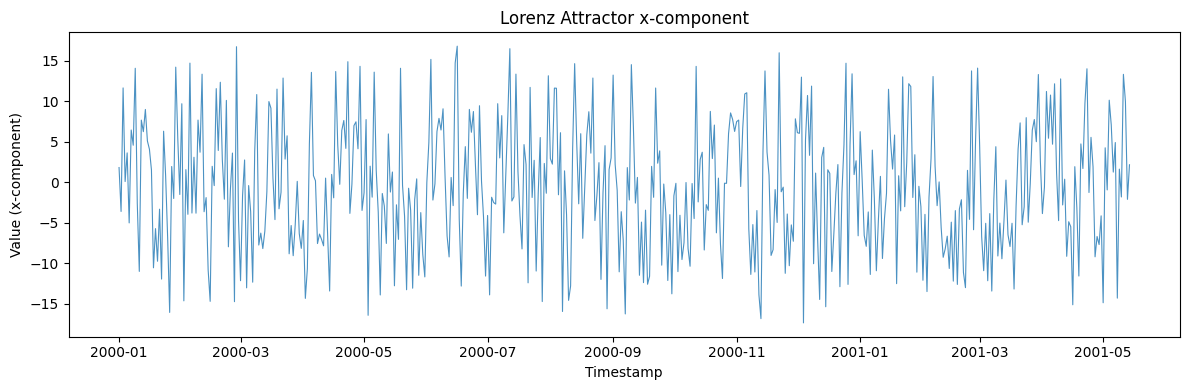

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lorenz_df["ds"].to_list(), lorenz_df["y"].to_list(), alpha=0.8, linewidth=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value (x-component)")
ax.set_title("Lorenz Attractor x-component")
plt.tight_layout()
plt.show()

## 2. Logistic map

The logistic map `x_{n+1} = r * x_n * (1 - x_n)` exhibits period-doubling cascades leading to chaos for r > 3.57.

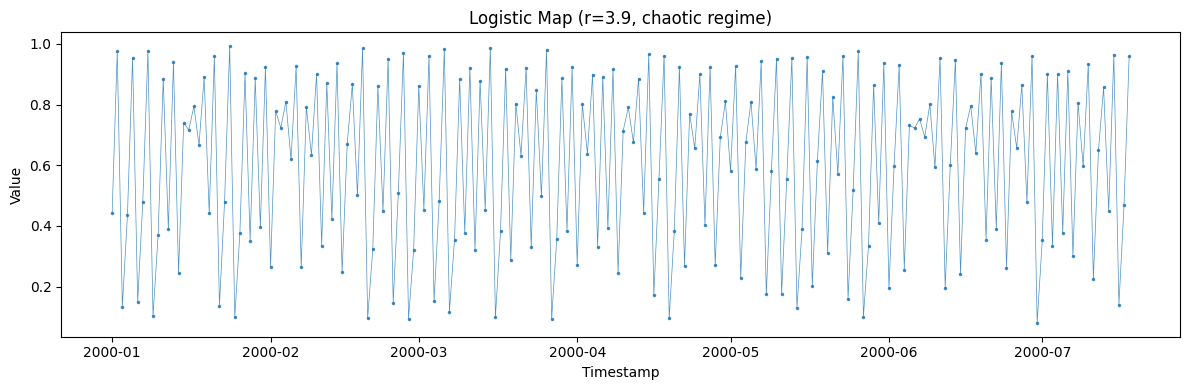

In [ ]:
logistic_gen = ChaoticSystemGenerator(engine="polars", 
    min_length=200,
    max_length=200,
    freq="D",
    system="logistic",
    logistic_r=3.9,
    observation_noise=0.01,
    seed=42,
)
logistic_df = logistic_gen.generate(n_series=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(logistic_df["ds"].to_list(), logistic_df["y"].to_list(), alpha=0.8, marker=".", markersize=3, linewidth=0.5)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Logistic Map (r=3.9, chaotic regime)")
plt.tight_layout()
plt.show()

## 3. Mackey-Glass delay equation

The Mackey-Glass system is a delay differential equation that produces complex, quasi-periodic dynamics. Chaos onset occurs for tau > 17.

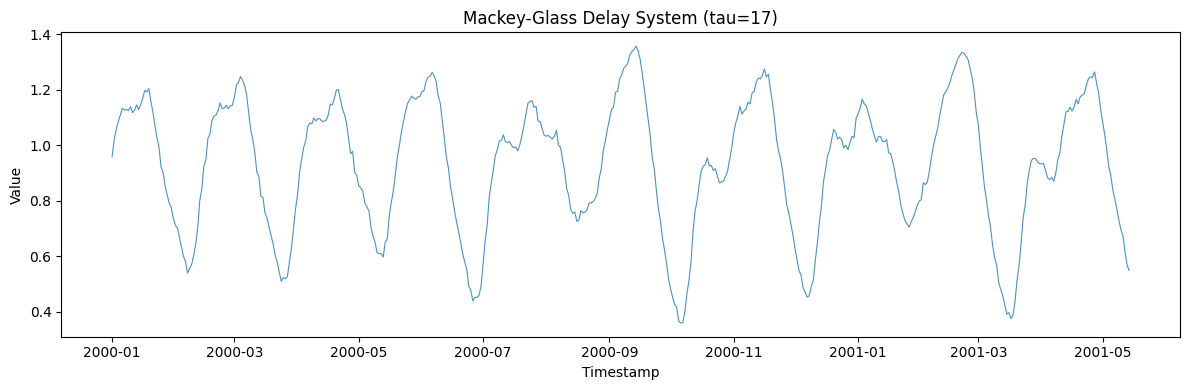

In [ ]:
mg_gen = ChaoticSystemGenerator(engine="polars", 
    min_length=500,
    max_length=500,
    freq="D",
    system="mackey_glass",
    mg_tau=17,
    observation_noise=0.01,
    seed=42,
)
mg_df = mg_gen.generate(n_series=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mg_df["ds"].to_list(), mg_df["y"].to_list(), alpha=0.8, linewidth=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Mackey-Glass Delay System (tau=17)")
plt.tight_layout()
plt.show()

## 4. Sensitivity to initial conditions

Multiple series from the same chaotic system diverge due to tiny differences in initial perturbations.

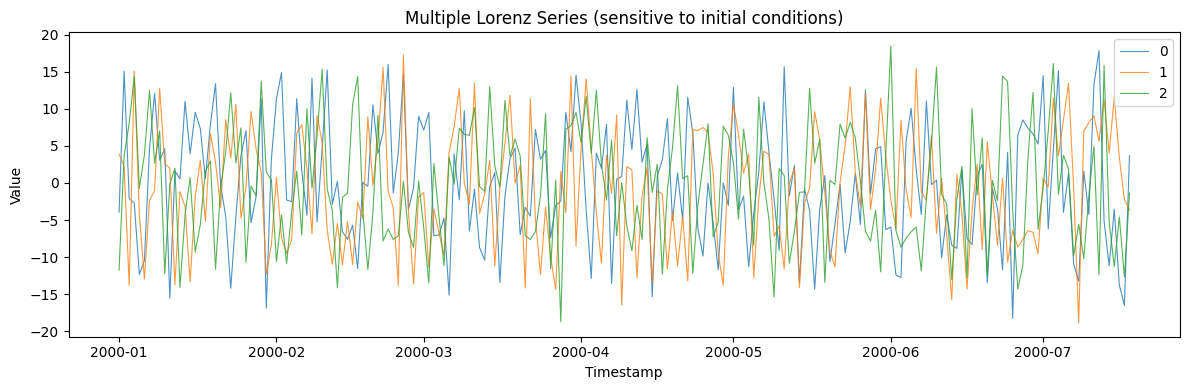

In [ ]:
multi_gen = ChaoticSystemGenerator(engine="polars", 
    min_length=200, max_length=200, freq="D",
    system="lorenz", seed=42,
)
multi_df = multi_gen.generate(n_series=3)

fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8, linewidth=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple Lorenz Series (sensitive to initial conditions)")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Cyclic](cyclic) — irregular but stochastic oscillation.
- [State space](../domain/state_space) — custom deterministic-plus-noise dynamics.

Available systems and parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::